In [24]:
import numpy as np
import pickle
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import plotting
import os
from proc_funcs import get_nodal_disparity_and_strength, run_roi_correlations

In [25]:
# 1. Mapeo a Lóbulos Anatómicos por índices AAL90
aal90_lobes = {}
for i in range(1, 91):
    roi = f"R{i}"
    if 1 <= i <= 28:
        aal90_lobes[roi] = 'Frontal'
    elif 43 <= i <= 54:
        aal90_lobes[roi] = 'Occipital'
    elif 57 <= i <= 70:
        aal90_lobes[roi] = 'Parietal'
    elif (55 <= i <= 56) or (79 <= i <= 90):
        aal90_lobes[roi] = 'Temporal'
    else: 
        # 29-42 (Insula, Cingulado, Hipocampo, Amígdala) y 71-78 (Ganglios Basales, Tálamo)
        aal90_lobes[roi] = 'Subcortical/Limbic'

# 2. Mapeo a Redes Yeo 7 por índices AAL90
yeo7_indices = {
    'Visual': list(range(43, 57)),
    'Somatomotor': [1, 2, 19, 20, 57, 58, 69, 70],
    'Default Mode': [23, 24, 35, 36, 65, 66, 67, 68],
    'Subcortical': [21, 22] + list(range(37, 43)) + list(range(71, 79)),
    'Fronto-Parietal': list(range(3, 9)) + list(range(59, 63)),
    'Ventral Attention': [29, 30, 33, 34, 63, 64],
    'Dorsal Attention': list(range(11, 17)) + [31, 32]
}

In [26]:



loaded = np.load('connectomes_harm_compressed.npz')
connectomes_harm = loaded['connectomes']

with open('data_age_harm.pkl', 'rb') as f:
    data_age_harm = pickle.load(f)
    
with open('data_harm.pkl', 'rb') as f:
    data_harm = pickle.load(f)
    
df_rois_disparities, df_rois_strengths = get_nodal_disparity_and_strength(connectomes_harm)

# Unimos con la edad y dataset de data_harm
df_full = pd.concat([data_harm[['age', 'dataset']], df_rois_disparities], axis=1)

c:\Users\Ale\Desktop\UB\NetLearn\proc_funcs.py:26: RuntimeWarning: invalid value encountered in divide
  nodal_Y = np.sum((adj / strength[:, None])**2, axis=1, where=valid[:, None])


In [27]:
# 1. Calcular fuerza media poblacional por ROI (N_rois, 1)
mean_strengths = df_rois_strengths.mean(axis=0).values.reshape(-1, 1)

# 2. Clustering de las regiones (Rich club, Feeder, Peripheral)
kmeans = KMeans(n_clusters=3, random_state=42)
roi_clusters = kmeans.fit_predict(mean_strengths)

# 3. Crear mapeo ROI -> Cluster
ROI_list = df_rois_strengths.columns
df_clusters = pd.DataFrame({'ROI': ROI_list, 'cluster': roi_clusters})

# 4. Correlación Masiva
results = run_roi_correlations(df_full, ROI_list, target_col='age', collapse_means=True)

# 5. Unir resultados con su respectivo cluster y resumir
results = results.merge(df_clusters, on='ROI')
cluster_summary = results.groupby('cluster')['r'].agg(['mean', 'std', 'count'])

print(cluster_summary)

c:\Users\Ale\miniconda3\envs\snakes\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


             mean       std  count
cluster                           
0        0.159728  0.389495     54
1       -0.077363  0.537936     33
2       -0.028569  0.768872      3


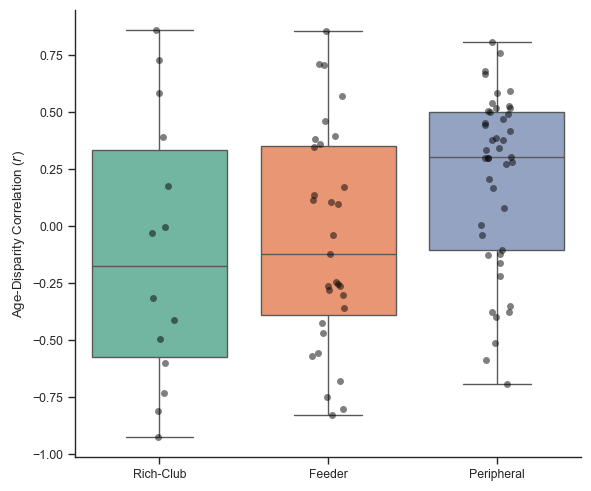

                mean       std  count
Club                                 
Feeder     -0.058597  0.474842     31
Peripheral  0.208972  0.384657     45
Rich-Club  -0.114330  0.590396     14


<Figure size 640x480 with 0 Axes>

In [28]:
# 1. Definir jerarquía poblacional (Popularidad/Hubness) 
mean_strengths = df_rois_strengths.mean(axis=0)
thresh_rich = mean_strengths.quantile(0.85)
thresh_feeder = mean_strengths.quantile(0.50)

def assign_club(s):
    if s >= thresh_rich: return 'Rich-Club'
    elif s >= thresh_feeder: return 'Feeder'
    else: return 'Peripheral'

# 2. Crear mapeo y ejecutar correlaciones una sola vez
df_clubs = pd.DataFrame({
    'ROI': mean_strengths.index,
    'Club': mean_strengths.apply(assign_club).values
})

# Ejecutamos la función de tu NB y unimos con la jerarquía y lóbulos
results = run_roi_correlations(df_full, df_rois_strengths.columns, target_col='age', collapse_means=True)
results = results.merge(df_clubs, on='ROI')

# Integrar lóbulos (usando el diccionario que definiste en la celda 4)
if 'aal90_lobes' in locals() or 'aal90_lobes' in globals():
    results['Lobe'] = results['ROI'].map(aal90_lobes)

# 3. Visualización corregida (Usando 'Club' consistentemente)
sns.set_theme(style="ticks", context="paper")
fig, ax = plt.subplots(figsize=(6, 5))

# Orden jerárquico lógico de hubs a periferia [cite: 404]
order = ['Rich-Club', 'Feeder', 'Peripheral']

# Usamos 'hue' para evitar bugs de paleta y asegurar el mapeo de colores
sns.boxplot(data=results, x='Club', y='r', order=order, ax=ax, palette='Set2', hue='Club', legend=False)
sns.stripplot(data=results, x='Club', y='r', order=order, ax=ax, color='black', alpha=0.5)

ax.set_ylabel('Age-Disparity Correlation ($r$)')
ax.set_xlabel('')
sns.despine()
plt.tight_layout()
plt.show()
plt.savefig('results/nodes/club_correlations.png', dpi=300)


# Resumen estadístico
print(results.groupby('Club')['r'].agg(['mean', 'std', 'count']))

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



aal90_yeo7 = {f"R{i}": net for net, indices in yeo7_indices.items() for i in indices}
for i in range(1, 91):
    aal90_yeo7.setdefault(f"R{i}", 'Other')

# 3. Aplicar al DataFrame
results['Lobe'] = results['ROI'].map(aal90_lobes)
results['Yeo7'] = results['ROI'].map(aal90_yeo7)



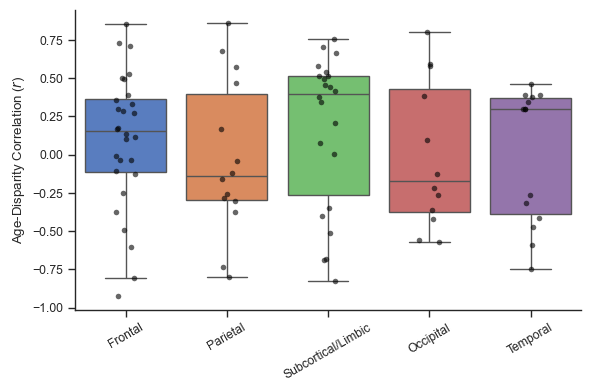

<Figure size 640x480 with 0 Axes>

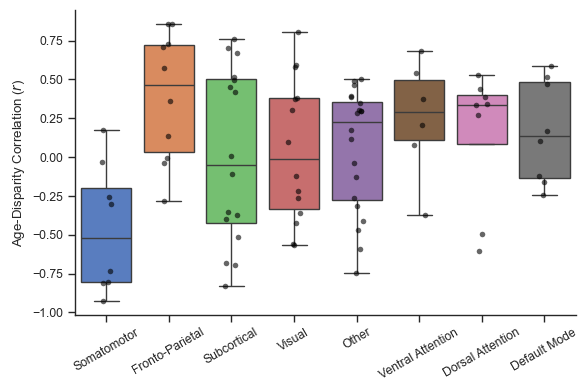

<Figure size 640x480 with 0 Axes>

In [10]:
# 4. Plots compactos (Estilo Paper)
sns.set_theme(style="ticks", context="paper")
plt.rc('axes', titlesize=0) 

# Lóbulos
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=results, x='Lobe', y='r', ax=ax, palette='muted', hue='Lobe',legend=False, showfliers=False)
sns.stripplot(data=results, x='Lobe', y='r', ax=ax, color='black', alpha=0.6, size=4)
ax.set_ylabel('Age-Disparity Correlation ($r$)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

plt.savefig('results/nodes/lobe_correlations.png', dpi=300)

# Yeo 7
fig2, ax2 = plt.subplots(figsize=(6, 4))
sns.boxplot(data=results, x='Yeo7', y='r', ax=ax2, palette='muted', hue='Yeo7',legend=False, showfliers=False)
sns.stripplot(data=results, x='Yeo7', y='r', ax=ax2, color='black', alpha=0.6, size=4)
ax2.set_ylabel('Age-Disparity Correlation ($r$)')
ax2.set_xlabel('')
#ax2.set_yscale('log')
ax2.tick_params(axis='x', rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

plt.savefig('results/nodes/yeo7_correlations.png', dpi=300)

Grouping nodes with community detection algorithms


--- Louvain Communities Summary ---
                     mean       std  count
Louvain_Cluster                           
C2               0.193304  0.482708     13
C1               0.183260  0.547894     14
C4               0.091867  0.431106     23
C3               0.046500  0.405232     27
C6              -0.041328  0.283852      7
C5              -0.361850  0.709115      6

--- Walktrap Communities Summary ---
                      mean       std  count
Walktrap_Cluster                           
C3                0.134309  0.435968     26
C1                0.045816  0.527891     39
C2                0.028312  0.415754     25

--- Surprise Communities Summary ---
                      mean       std  count
Surprise_Cluster                           
C11               0.601321  0.146032      2
C29               0.582774       NaN      1
C20               0.525606       NaN      1
C9                0.522697  0.065640      3
C25               0.502659       NaN      1
C26            

C:\Users\Ale\AppData\Local\Temp\ipykernel_14396\3331122999.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_comm, x=col, y='r', order=order, ax=ax, palette='muted', showfliers=False)
C:\Users\Ale\AppData\Local\Temp\ipykernel_14396\3331122999.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_comm, x=col, y='r', order=order, ax=ax, palette='muted', showfliers=False)
C:\Users\Ale\AppData\Local\Temp\ipykernel_14396\3331122999.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_comm, x=col, y='r', or

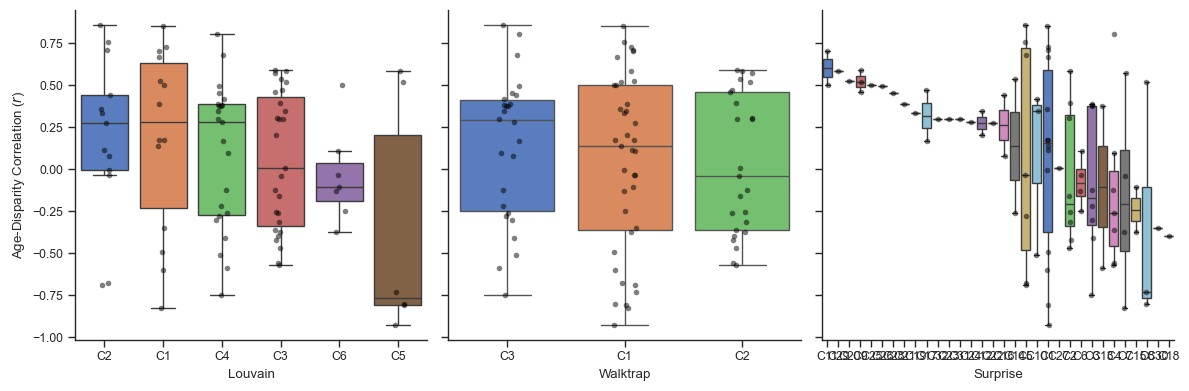

<Figure size 640x480 with 0 Axes>

In [ ]:
# !pip install igraph leidenalg
import numpy as np
import pandas as pd
import igraph as ig
import leidenalg
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Build the Base Structural Network (Young Adults)
# Averaging young subjects to find the "healthy baseline" topology
young_idx = df_full['age'] <= 30
W_base = connectomes_harm[young_idx].mean(axis=0)

# Zero the diagonal and optionally threshold to remove noise 
# (e.g., keeping only edges > 0 is fine if the matrix is already sparse)
np.fill_diagonal(W_base, 0)
edges = np.argwhere(W_base > 0)
weights = W_base[W_base > 0]

# Create igraph object
g = ig.Graph(n=90, edges=edges.tolist(), directed=False)
g.es['weight'] = weights

# 2. Run the 3 Community Detection Algorithms
partitions = {}

# A) Louvain (Multilevel)
louvain_part = g.community_multilevel(weights='weight')
partitions['Louvain'] = louvain_part.membership

# B) Walktrap (Random-walk based)
# Steps usually set between 3 and 5
walktrap_part = g.community_walktrap(weights='weight', steps=4).as_clustering()
partitions['Walktrap'] = walktrap_part.membership

# C) Surprise (Optimized via Leiden algorithm)
surprise_part = leidenalg.find_partition(g, leidenalg.SurpriseVertexPartition, weights='weight')
partitions['Surprise'] = surprise_part.membership

# 3. Map Communities to ROIs and Merge with Results
df_comm = pd.DataFrame({'ROI': ROI_list})

for algo_name, membership in partitions.items():
    # Convert arbitrary cluster IDs to string labels (e.g., 'C1', 'C2')
    df_comm[f'{algo_name}_Cluster'] = [f"C{m+1}" for m in membership]

# Assume 'results' is the DataFrame containing 'ROI', 'r', and 'p_val' from run_roi_correlations
results_comm = results.merge(df_comm, on='ROI')

# 4. Summarize and Plot the structural deterioration per community
for algo in ['Louvain', 'Walktrap', 'Surprise']:
    col = f'{algo}_Cluster'
    print(f"\n--- {algo} Communities Summary ---")
    summary = results_comm.groupby(col)['r'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
    print(summary)

# 5. Visual Comparison (Compact Paper Style)
sns.set_theme(style="ticks", context="paper")
plt.rc('axes', titlesize=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, algo in zip(axes, ['Louvain', 'Walktrap', 'Surprise']):
    col = f'{algo}_Cluster'
    
    # Sort clusters by their mean 'r' for better visualization
    order = results_comm.groupby(col)['r'].mean().sort_values(ascending=False).index
    
    sns.boxplot(data=results_comm, x=col, y='r', order=order, ax=ax, palette='muted', showfliers=False)
    sns.stripplot(data=results_comm, x=col, y='r', order=order, ax=ax, color='black', alpha=0.5, size=4)
    
    ax.set_xlabel(algo)
    if ax == axes[0]:
        ax.set_ylabel('Age-Disparity Correlation ($r$)')
    else:
        ax.set_ylabel('')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

plt.savefig('results/nodes/community_detection_comparisson.png', dpi=300)

!! group representative connectome. cuales son los quesitos en regiones de comunidades

In [12]:

ruta_atlas_nii = os.path.join('./preprocdata/aal-SPM12/aal/atlas/', 'AAL.nii')
coords = plotting.find_parcellation_cut_coords(ruta_atlas_nii)
coords_90 = coords[:90] #without cerebellum


¿Qué predice el aumento de disparidad (r)?
Base_Clustering: R = -0.128 (p = 0.228)
Base_Betweenness: R = 0.059 (p = 0.580)
Base_Strength: R = -0.226 (p = 0.032)
Base_WiringCost: R = 0.085 (p = 0.426)


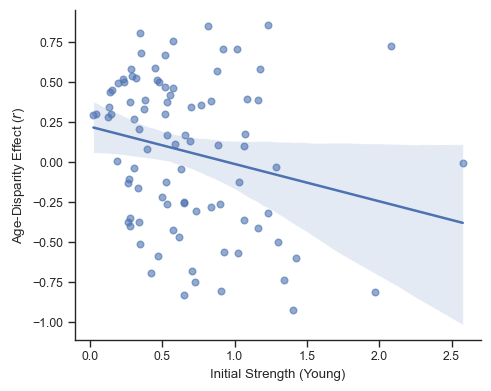

In [13]:
import numpy as np
import pandas as pd
import networkx as nx
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtener la red base (Jóvenes) para extraer sus propiedades
idx_young = df_full['age'] <= 30
W_young = connectomes_harm[idx_young].mean(axis=0)
np.fill_diagonal(W_young, 0)

# Crear grafo en NetworkX
G = nx.from_numpy_array(W_young)

# 2. Calcular Propiedades Topológicas Base
# A) Clustering local (Weighted)
clustering = nx.clustering(G, weight='weight')
# B) Betweenness Centrality
betweenness = nx.betweenness_centrality(G, weight='weight')
# C) Degree / Strength (para control)
strength = dict(G.degree(weight='weight'))

# 3. Calcular Propiedades Físicas (Wiring Cost)
# coords_90 es tu array (90, 3) con las coordenadas MNI
dist_matrix = squareform(pdist(coords_90))
wiring_costs = {}
for i in range(90):
    # Distancia media ponderada por los pesos de las conexiones reales del nodo
    weights = W_young[i, :]
    if np.sum(weights) > 0:
        wiring_costs[i] = np.average(dist_matrix[i, :], weights=weights)
    else:
        wiring_costs[i] = 0

# 4. Unir todo en un DataFrame
# Asumo que 'results' tiene columnas ['ROI', 'r'] (donde r es la correlación edad-disparidad)
df_predict = pd.DataFrame({
    'ROI': [f"R{i+1}" for i in range(90)],
    'Base_Clustering': list(clustering.values()),
    'Base_Betweenness': list(betweenness.values()),
    'Base_Strength': list(strength.values()),
    'Base_WiringCost': list(wiring_costs.values())
})

df_predict = df_predict.merge(results[['ROI', 'r']], on='ROI')

# 5. Buscar la "Señal" (Correlaciones)
print("¿Qué predice el aumento de disparidad (r)?")
for col in ['Base_Clustering', 'Base_Betweenness', 'Base_Strength', 'Base_WiringCost']:
    corr, p = pearsonr(df_predict[col], df_predict['r'])
    print(f"{col}: R = {corr:.3f} (p = {p:.3f})")

# 6. Plot del mejor predictor (Ej: si Wiring Cost sale bien)
sns.set_theme(style="ticks", context="paper")
fig, ax = plt.subplots(figsize=(5, 4))
sns.regplot(data=df_predict, x='Base_Strength', y='r', ax=ax, scatter_kws={'alpha':0.6})
ax.set_xlabel('Initial Strength (Young)')
ax.set_ylabel('Age-Disparity Effect ($r$)')
sns.despine()
plt.tight_layout()
plt.show()



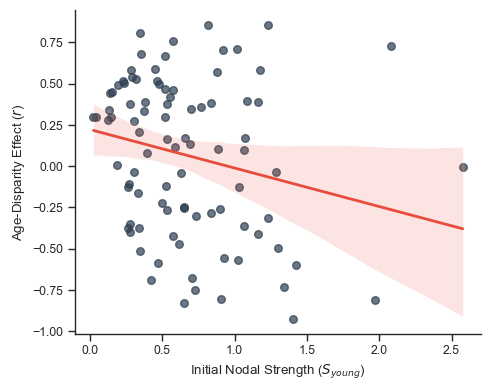

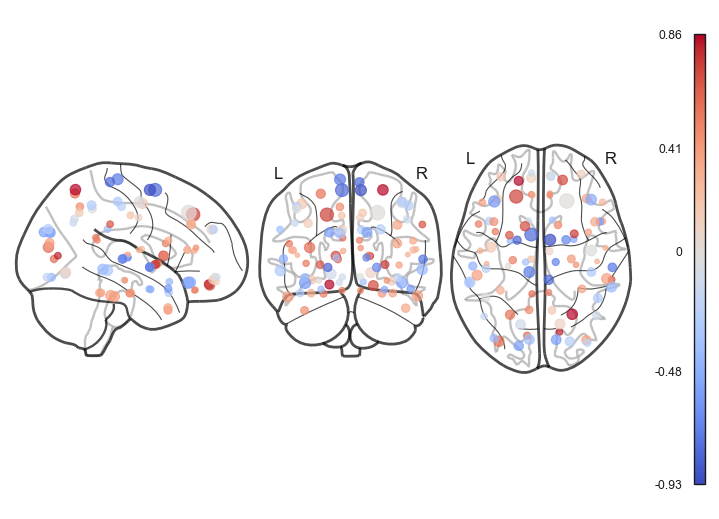

<Figure size 640x480 with 0 Axes>

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import plotting
import numpy as np

# Configuración estricta para paper
sns.set_theme(style="ticks", context="paper")
plt.rc('axes', titlesize=0)

# 1. Figura Estadística: Regresión Lineal
fig, ax = plt.subplots(figsize=(5, 4))
sns.regplot(
    data=df_predict, 
    x='Base_Strength', 
    y='r', 
    ax=ax, 
    scatter_kws={'alpha': 0.7, 'color': '#2c3e50', 's': 30}, 
    line_kws={'color': '#e74c3c', 'linewidth': 2}
)

ax.set_xlabel('Initial Nodal Strength ($S_{young}$)')
ax.set_ylabel('Age-Disparity Effect ($r$)')
sns.despine()
plt.tight_layout()
plt.show()

# 2. Figura Topológica: Proyección Espacial
# Tamaño del nodo: Fuerza Inicial (Core = grande, Periferia = pequeño)
sizes = (df_predict['Base_Strength'] / df_predict['Base_Strength'].max()) * 100 + 10

# Color del nodo: Magnitud del aumento de disparidad
colors = df_predict['r'].values

fig2 = plt.figure(figsize=(7, 5))
display = plotting.plot_markers(
    node_values=colors,
    node_coords=coords_90,
    node_size=sizes,
    node_cmap='coolwarm',
    colorbar=True,
    figure=fig2
)
plt.show()

plt.savefig('results/nodes/strength_correlation.png', dpi=300)

entonces se ve que cuanta menos fuerza mas crece la disparidad...

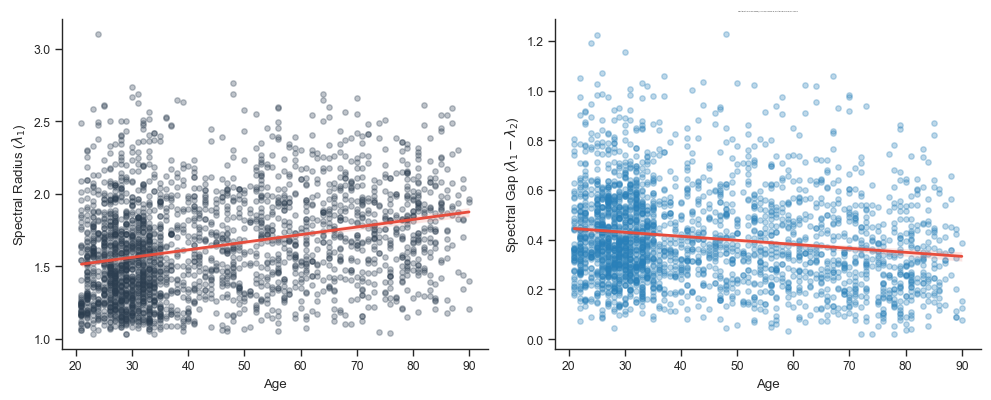

Lambda_1 vs Age: R = 0.290 (p = 9.581e-49)
Spectral Gap vs Age: R = -0.165 (p = 1.954e-16)


<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import pandas as pd
import scipy.linalg as la
import seaborn as sns
import matplotlib.pyplot as plt

# Asumo que data_harm tiene las edades y connectomes_harm tiene tus matrices (N_subj, 90, 90)

spectral_metrics = []

for i in range(len(connectomes_harm)):
    W = connectomes_harm[i]
    
    # Calcular autovalores reales (W es simétrica)
    eigenvalues = la.eigvalsh(W)
    
    # Sort descending
    eigenvalues = np.sort(eigenvalues)[::-1]
    
    l1 = eigenvalues[0]
    l2 = eigenvalues[1]
    gap = l1 - l2
    
    spectral_metrics.append({
        'lambda_1': l1,
        'spectral_gap': gap
    })

df_spec = pd.DataFrame(spectral_metrics)
df_spec['age'] = data_harm['age']

# Filtrar adultos si es necesario (ej. age > 20)
df_adults = df_spec[df_spec['age'] > 20]

# --- Visualización Estilo Paper ---
sns.set_theme(style="ticks", context="paper")
plt.rc('axes', titlesize=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 1. Radio Espectral vs Edad
sns.regplot(
    data=df_adults, x='age', y='lambda_1', ax=axes[0],
    scatter_kws={'alpha': 0.3, 's': 15, 'color': '#2c3e50'},
    line_kws={'color': '#e74c3c', 'linewidth': 2}
)
axes[0].set_ylabel(r'Spectral Radius ($\lambda_1$)')
axes[0].set_xlabel('Age')

# 2. Spectral Gap vs Edad
sns.regplot(
    data=df_adults, x='age', y='spectral_gap', ax=axes[1],
    scatter_kws={'alpha': 0.3, 's': 15, 'color': '#2980b9'},
    line_kws={'color': '#e74c3c', 'linewidth': 2}
)
axes[1].set_ylabel(r'Spectral Gap ($\lambda_1 - \lambda_2$)')
axes[1].set_xlabel('Age')

sns.despine()
plt.tight_layout()


# Estadísticas
import scipy.stats as stats
r1, p1 = stats.pearsonr(df_adults['age'], df_adults['lambda_1'])
r2, p2 = stats.pearsonr(df_adults['age'], df_adults['spectral_gap'])

plt.title("Spectral Metrics vs Age. Lambda_1: R={:.3f}, p={:.3e}; Spectral Gap: R={:.3f}, p={:.3e}".format(r1, p1, r2, p2))
plt.show()


print(f"Lambda_1 vs Age: R = {r1:.3f} (p = {p1:.3e})")
print(f"Spectral Gap vs Age: R = {r2:.3f} (p = {p2:.3e})")

plt.savefig('results/nodes/spectral_metrics_correlation.png', dpi=300)

!hacer media antes de hacer la correlacion
!! repetir estas metricas para la laplaciana

c:\Users\Ale\miniconda3\envs\snakes\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


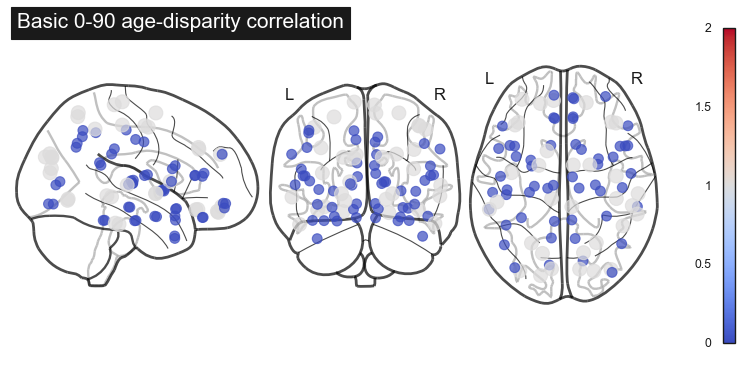

In [16]:
# Ensure ROI order matches coords_90 (R1...R90)
df_plot = df_clusters.copy()
df_plot['roi_idx'] = df_plot['ROI'].str.extract(r'(\d+)').astype(int)
df_plot = df_plot.sort_values('roi_idx')

# Convert string clusters to numeric codes
df_plot['cluster_code'] = pd.Categorical(df_plot['cluster']).codes
aligned_clusters = df_plot['cluster_code'].to_numpy()

plotting.plot_markers(
    node_values=aligned_clusters,
    node_coords=coords_90,
    node_cmap='coolwarm',
    node_size=(aligned_clusters + 1) * 50,
    title="Basic 0-90 age-disparity correlation"
)


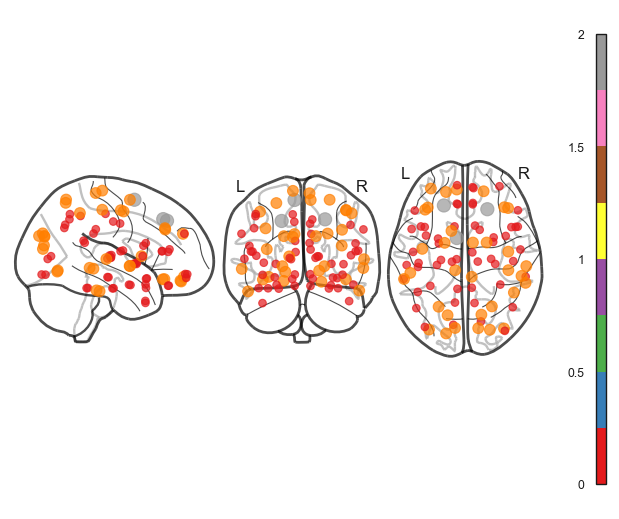

In [17]:
# 1. Extract the aligned array of cluster labels


aligned_clusters = df_plot['cluster_code'].to_numpy()

# 2. Plotting (Compact figure, no title)
fig = plt.figure(figsize=(6, 5))

plotting.plot_markers(
    node_values=aligned_clusters, 
    node_coords=coords_90, 
    node_cmap='Set1', 
    # Add 1 so cluster 0 doesn't disappear, multiply by a base size
    node_size=(aligned_clusters + 1) * 30, 
    figure=fig
)

plt.show()

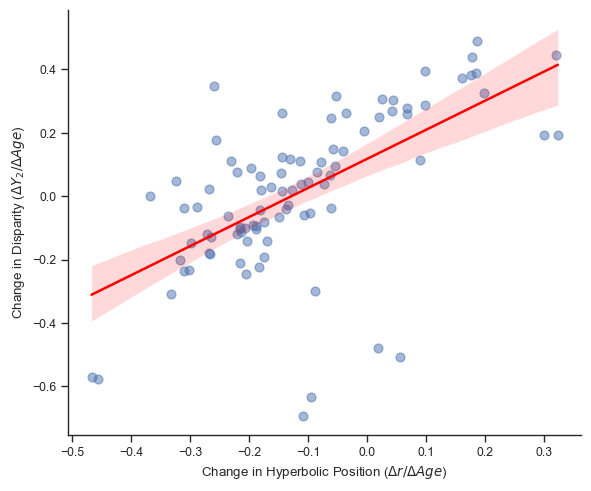

Correlation between Structural Hierarchy change and Disparity change: 0.649 (p=4.5396e-12)


In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# 1. Función de mapeo para obtener el radio (Popularidad)
def get_hyperbolic_r(adj_matrix):
    N = adj_matrix.shape[0]
    s = np.sum(adj_matrix, axis=1)
    s_min = np.min(s[s > 0]) if np.any(s > 0) else 1e-6
    R = 2 * np.log(N)
    # r cuantifica la posición en la jerarquía: r -> 0 es Hub, r -> R es periferia [cite: 114, 131]
    r = R - 2 * np.log(s / s_min + 1e-9)
    return np.clip(r, 0, R)

# 2. Sample de 100 sujetos (evitamos sesgos de grupos extremos)
n_sample = 3000
sample_indices = data_harm.sample(n=n_sample, random_state=42).index

# 3. Recolección de métricas dinámicas
subjects_r = []
for idx in sample_indices:
    subjects_r.append(get_hyperbolic_r(connectomes_harm[idx]))

df_r_sample = pd.DataFrame(subjects_r, index=sample_indices, columns=df_rois_disparities.columns)
df_d_sample = df_rois_disparities.loc[sample_indices]
ages_sample = data_harm.loc[sample_indices, 'age']

# 4. Análisis de Correlación de "Cambio"
# Queremos ver si el cambio en r (jerarquía) explica el cambio en disparidad
roi_stats = []
for roi in df_r_sample.columns:
    # Trayectoria de la jerarquía con la edad
    corr_r_age, _ = spearmanr(ages_sample, df_r_sample[roi])
    # Trayectoria de la disparidad con la edad (tu métrica original)
    corr_d_age, _ = spearmanr(ages_sample, df_d_sample[roi])
    # Correlación directa entre r y disparidad para este nodo
    corr_r_d, _ = spearmanr(df_r_sample[roi], df_d_sample[roi])
    
    roi_stats.append({
        'ROI': roi,
        'Hierarchy_Change_with_Age': corr_r_age,   # + significa que el nodo se vuelve más periférico
        'Disparity_Change_with_Age': corr_d_age,   # + significa que el nodo se vuelve más dispar
        'Hyperbolic_Radius_Avg': df_r_sample[roi].mean()
    })

df_analysis = pd.DataFrame(roi_stats)

# 5. Visualización Estilo Paper (6,5)
sns.set_context("paper")
sns.set_style("ticks")
fig, ax = plt.subplots(figsize=(6, 5))

# Test: ¿Los nodos que más "caen" en la jerarquía (r aumenta) son los que más aumentan su disparidad?
sns.regplot(data=df_analysis, x='Hierarchy_Change_with_Age', y='Disparity_Change_with_Age', 
            scatter_kws={'alpha':0.5, 's':40}, line_kws={'color':'red'}, ax=ax)

ax.set_xlabel('Change in Hyperbolic Position ($\Delta r / \Delta Age$)')
ax.set_ylabel('Change in Disparity ($\Delta Y_2 / \Delta Age$)')
sns.despine()
plt.tight_layout()
plt.show()

# 6. Métrica de validación
global_corr, p_val = spearmanr(df_analysis['Hierarchy_Change_with_Age'], df_analysis['Disparity_Change_with_Age'])
print(f"Correlation between Structural Hierarchy change and Disparity change: {global_corr:.3f} (p={p_val:.4e})")

In [19]:
df_plot.columns
df_analysis.columns

Index(['ROI', 'Hierarchy_Change_with_Age', 'Disparity_Change_with_Age',
       'Hyperbolic_Radius_Avg'],
      dtype='object')

In [20]:
df_analysis.columns

Index(['ROI', 'Hierarchy_Change_with_Age', 'Disparity_Change_with_Age',
       'Hyperbolic_Radius_Avg'],
      dtype='object')

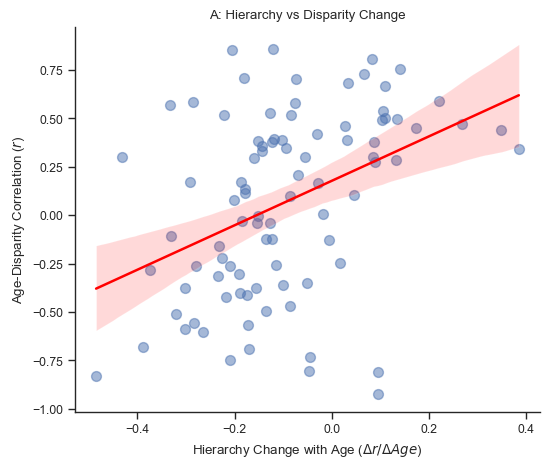

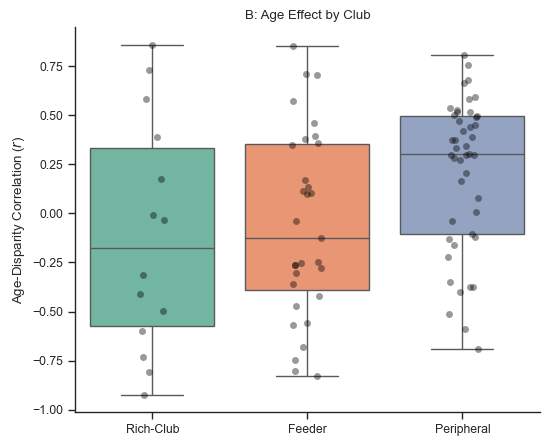

Global Correlation (Hierarchy vs Disparity): 0.420 (p=3.8522e-05)


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# 1. Definir función para el Radio Hiperbólico (Popularidad)
# En el modelo H2, el radio r se deriva del strength (popularidad) [cite: 114, 131]
def calculate_hyperbolic_r(adj_matrix):
    N = adj_matrix.shape[0]
    s = np.sum(adj_matrix, axis=1)
    s_min = np.min(s[s > 0]) if np.any(s > 0) else 1e-6
    R = 2 * np.log(N)
    # Los nodos con mayor strength (hubs) tienen r menor (más centrales) [cite: 131, 404]
    r = R - 2 * np.log(np.maximum(s, s_min) / s_min + 1e-9)
    return np.clip(r, 0, R)

# 2. Procesar un sample de 100 sujetos para métricas dinámicas
n_sample = 100
sample_idx = data_harm.sample(n=n_sample, random_state=42).index
ages_sample = data_harm.loc[sample_idx, 'age']

# Calculamos el radio hiperbólico para cada ROI en cada sujeto del sample
r_data = []
for idx in sample_idx:
    r_data.append(calculate_hyperbolic_r(connectomes_harm[idx]))

df_r_sample = pd.DataFrame(r_data, index=sample_idx, columns=df_rois_disparities.columns)

# 3. Calcular la correlación de la jerarquía con la edad para cada ROI
hierarchy_age_corr = {}
for roi in df_r_sample.columns:
    corr, _ = spearmanr(ages_sample, df_r_sample[roi])
    hierarchy_age_corr[roi] = corr

# 4. Integrar todo en el DataFrame 'results'
# 'Hierarchy_Age_r' + significa que el nodo se vuelve más periférico con la edad
results['Hierarchy_Age_r'] = results['ROI'].map(hierarchy_age_corr)
results['Mean_Hyperbolic_r'] = results['ROI'].map(df_r_sample.mean())

# 5. Generación de Gráficos (Estilo Paper)
sns.set_theme(style="ticks", context="paper")

# Plot A: ¿El cambio en la jerarquía explica el cambio en la disparidad?
fig1, ax1 = plt.subplots(figsize=(6, 5))
sns.regplot(data=results, x='Hierarchy_Age_r', y='r', 
            scatter_kws={'alpha':0.5, 's':50}, line_kws={'color':'red'}, ax=ax1)
ax1.set_xlabel('Hierarchy Change with Age ($\Delta r / \Delta Age$)')
ax1.set_ylabel('Age-Disparity Correlation ($r$)')
ax1.set_title('A: Hierarchy vs Disparity Change')
sns.despine()

# Plot B: Estratificación Radial del efecto de la edad
fig2, ax2 = plt.subplots(figsize=(6, 5))
order = ['Rich-Club', 'Feeder', 'Peripheral']
sns.boxplot(data=results, x='Club', y='r', order=order, palette='Set2', hue='Club', legend=False, ax=ax2)
sns.stripplot(data=results, x='Club', y='r', order=order, color='black', alpha=0.4, ax=ax2)
ax2.set_xlabel('')
ax2.set_ylabel('Age-Disparity Correlation ($r$)')
ax2.set_title('B: Age Effect by Club')
sns.despine()

plt.show()

# Resumen de validación
global_corr, p_val = spearmanr(results['Hierarchy_Age_r'], results['r'])
print(f"Global Correlation (Hierarchy vs Disparity): {global_corr:.3f} (p={p_val:.4e})")

!mirar la distancia hiperbolica
!animación con el disco y como cambia con el centro. (y sanapshots)
!checkear sexo y neurodivergentes. 
!group representative con los neurodivergentes
!sacar los neurodivergentes y repetir los analisis para un group representative de ellos. 

In [22]:
def get_subject_hyperbolic(adj_matrix):
    """Calcula coordenadas basadas en el strength individual."""
    N = adj_matrix.shape[0]
    # Strength es la suma de pesos, base de la 'popularidad' radial[cite: 131, 138].
    s = np.sum(adj_matrix, axis=1)
    s_min = np.min(s[s > 0]) if np.any(s > 0) else 1
    s_safe = np.maximum(s, s_min)
    
    # R define el borde del disco[cite: 118, 132].
    R = 2 * np.log(N)
    # r_i: los nodos con mayor strength se sitúan más cerca del centro.
    r = R - 2 * np.log(s_safe / s_min)
    
    # Theta: Para este plot, usamos el orden anatómico de tus ROIs (AAL90) 
    # como proxy de similitud para ver clusters por lóbulos[cite: 446, 510].
    theta = np.linspace(0, 2*np.pi, N, endpoint=False)
    return r, theta

In [29]:
from hyperbolic_map import compute_greedy_routing_metrics


# 2. Análisis Poblacional (Sample de 100)
pop_metrics = []
for idx in sample_idx:
    adj = connectomes_harm[idx]
    r, theta = get_subject_hyperbolic(adj) # Tu función anterior
    sr, stretch = compute_greedy_routing_metrics(adj, r, theta)
    
    pop_metrics.append({
        'idx': idx,
        'age': data_harm.loc[idx, 'age'],
        'Success_Rate': sr,
        'Stretch': stretch,
        'Mean_Disparity': df_rois_disparities.loc[idx].mean()
    })

df_hyper = pd.DataFrame(pop_metrics)

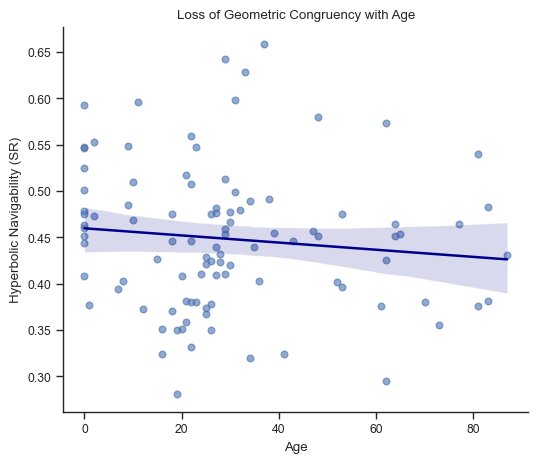

<Figure size 640x480 with 0 Axes>

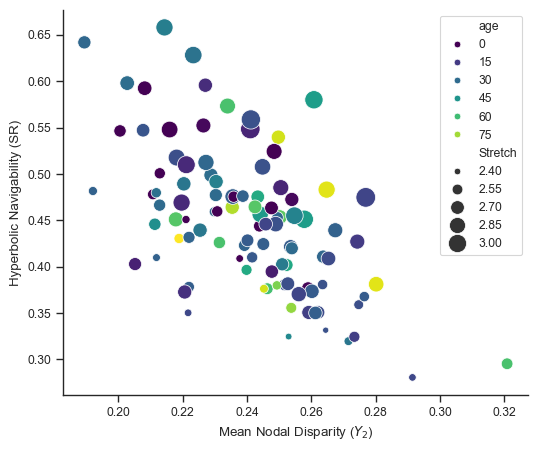

<Figure size 640x480 with 0 Axes>

In [30]:
sns.set_context("paper")
fig, ax = plt.subplots(figsize=(6, 5))

sns.regplot(data=df_hyper, x='age', y='Success_Rate', 
            scatter_kws={'alpha':0.6}, line_kws={'color':'darkblue'}, ax=ax)

ax.set_ylabel('Hyperbolic Navigability (SR)')
ax.set_xlabel('Age')
ax.set_title('Loss of Geometric Congruency with Age')
sns.despine()
plt.show()
plt.savefig('results/nodes/hyperbolic_navigability_age.png', dpi=300)

fig, ax = plt.subplots(figsize=(6, 5))

# Relación entre la disparidad (no lineal) y la navegabilidad (congruencia)
sns.scatterplot(data=df_hyper, x='Mean_Disparity', y='Success_Rate', 
                hue='age', palette='viridis', size='Stretch', sizes=(20, 200), ax=ax)

ax.set_xlabel('Mean Nodal Disparity ($Y_2$)')
ax.set_ylabel('Hyperbolic Navigability (SR)')
sns.despine()
plt.show()
plt.savefig('results/nodes/hyperbolic_navigability.png', dpi=300)